# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Timothy Felix
- **Email:** timothyfelix2004@gmail.com
- **ID Dicoding:** timothyfelix

## Menentukan Pertanyaan Bisnis

**Pertanyaan 1:** Seberapa besar persentase penurunan rata-rata penyewaan sepeda harian saat terjadi cuaca buruk dibandingkan cuaca cerah hingga mencapai penurunan di atas 50 persen di setiap musim sepanjang periode 2011 hingga 2012?

Keterangan :

*   **Specific**: Fokus mengukur dampak perubahan kondisi dari cuaca
cerah ke cuaca buruk terhadap total penyewaan sepeda harian di setiap musim.
*   **Measurable**: Memiliki metrik dan acuan batas kuantitatif yang jelas, yaitu persentase penurunan rata-rata penyewaan harian yang melebihi 50 persen.
*   **Action-Oriented**: Hasil analisis memberikan acuan angka bagi manajemen untuk efisiensi biaya pemeliharaan unit dan penyiapan program promosi khusus saat cuaca buruk.
*   **Relevant**: Penting bagi bisnis untuk mengukur potensi penurunan pendapatan dan efisiensi operasional akibat cuaca ekstrem.
*   **Time-bound**: Dibatasi pada rentang data historis tahun 2011 hingga 2012.

**Pertanyaan 2**: Seberapa besar lonjakan rata-rata volume peminjaman per jam pada jam sibuk di hari kerja oleh pengguna terdaftar dan di hari libur oleh pengguna kasual hingga mencapai lebih dari 3,5 kali lipat dibandingkan jam biasa sepanjang periode 2011 hingga 2012?

Keterangan :
*   **Specific**: Mengukur secara spesifik lonjakan volume peminjaman pada jam sibuk (peak hours) untuk dua segmen terpisah: pengguna terdaftar (registered) pada hari kerja dan pengguna kasual (casual) pada hari libur.
*   **Measurable**: Memiliki metrik perbandingan kuantitatif yang jelas dan terukur dari data, yaitu tingkat lonjakan volume peminjaman di jam sibuk yang melebihi 3,5 kali lipat dibandingkan rata-rata jam biasa (data riil menunjukkan lonjakan rata-rata pengguna terdaftar di jam 08.00 & 17.00 sebesar 3,63x, dan pengguna kasual di jam 12.00–16.00 sebesar 3,59x).
*   **Action-Oriented**:Hasil analisis dapat menjadi dasar bagi tim operasional dalam mengantisipasi kebutuhan unit sepeda pada periode dengan lonjakan permintaan.
*   **Relevant**: Mengantisipasi lonjakan ekstrim pada jam sibuk sangat krusial untuk mencegah penumpukan atau kekurangan unit sepeda di lokasi strategis.
*   **Time-bound**: Dibatasi pada rentang data historis tahun 2011 hingga 2012.









## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
# Memuat data ke DataFrame
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

In [3]:
print("=== Preview Data Harian (day.csv) ===")
display(day_df.head())

=== Preview Data Harian (day.csv) ===


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
print("\n=== Preview Data Per Jam (hour.csv) ===")
display(hour_df.head())


=== Preview Data Per Jam (hour.csv) ===


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Assessing Data

In [5]:
print("=== INFO DAY DF ===")
day_df.info()

print("\n=== MISSING VALUES DAY DF ===")
print(day_df.isnull().sum())

print("\n=== DUPLIKAT DAY DF ===")
print("Jumlah duplikat:", day_df.duplicated().sum())

=== INFO DAY DF ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

=== MISSING VALUES DAY DF ===
instant       0
dteday        0
season    

In [6]:
print("=== INFO HOUR DF ===")
hour_df.info()

print("\n=== MISSING VALUES HOUR DF ===")
print(hour_df.isnull().sum())

print("\n=== DUPLIKAT HOUR DF ===")
print("Jumlah duplikat:", hour_df.duplicated().sum())

=== INFO HOUR DF ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

=== MISSING VALUES HOUR DF 

**Hasil Penilaian Kualitas Data (Assessing Data):**
1. **Kesalahan Tipe Data:**
   - Kolom `dteday` pada `day_df` dan `hour_df` bertipe data `object` (string). Kolom ini seharusnya diubah menjadi tipe data `datetime`.
2. **Missing Values & Duplikat:**
   - Tidak ditemukan adanya *missing value* maupun data duplikat pada kedua DataFrame (semua terisi penuh dan unik).
3. **Penyesuaian Label Kategorikal:**
   - Kolom kategorikal seperti `season` dan `weathersit` masih berupa kode angka ($1, 2, 3 \dots$). Pada tahap *Cleaning Data*, saya akan menambahkan kolom penjelas agar visualisasi lebih informatif.

### Cleaning Data

In [7]:
# 1. Mengubah tipe data dteday menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# 2. Pemetaan label kategorikal untuk season
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
day_df['season'] = day_df['season'].map(season_mapping)
hour_df['season'] = hour_df['season'].map(season_mapping)

# 3. Pemetaan label kategorikal untuk weathersit
weather_mapping = {
    1: 'Clear/Partly Cloudy',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Severe Weather'
}
day_df['weathersit'] = day_df['weathersit'].map(weather_mapping)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_mapping)

# 4. Pemetaan label kategorikal untuk yr (tahun)
year_mapping = {0: '2011', 1: '2012'}
day_df['yr'] = day_df['yr'].map(year_mapping)
hour_df['yr'] = hour_df['yr'].map(year_mapping)

# Memeriksa hasil pembersihan data
print("=== Tipe Data dteday Setelah Diubah ===")
print("day_df:", day_df['dteday'].dtype)
print("hour_df:", hour_df['dteday'].dtype)

print("\n=== Sample Hasil Pembersihan Data (day_df) ===")
display(day_df[['dteday', 'season', 'yr', 'weathersit', 'cnt']].head())

=== Tipe Data dteday Setelah Diubah ===
day_df: datetime64[ns]
hour_df: datetime64[ns]

=== Sample Hasil Pembersihan Data (day_df) ===


,dteday,season,yr,weathersit,cnt
0,2011-01-01,Spring,2011,Misty/Cloudy,985
1,2011-01-02,Spring,2011,Misty/Cloudy,801
2,2011-01-03,Spring,2011,Clear/Partly Cloudy,1349
3,2011-01-04,Spring,2011,Clear/Partly Cloudy,1562
4,2011-01-05,Spring,2011,Clear/Partly Cloudy,1600


**Hasil Pembersihan Data (Cleaning Data):**
- Kolom `dteday` telah berhasil diubah menjadi tipe data `datetime`.
- Kolom `season`, `weathersit`, dan `yr` telah dipetakan menjadi label berupa teks deskriptif (misal: 'Spring', 'Clear/Partly Cloudy', '2011') sehingga siap digunakan dalam proses Exploratory Data Analysis (EDA) dan visualisasi.

## Exploratory Data Analysis (EDA)

In [8]:
# 1. Rangkuman statistik deskriptif untuk data harian (day_df)
print("=== Statistik Deskriptif Data Harian (day_df) ===")
display(day_df.describe(include='all'))

# 2. Rangkuman statistik deskriptif untuk data per jam (hour_df)
print("\n=== Statistik Deskriptif Data Per Jam (hour_df) ===")
display(hour_df.describe(include='all'))

=== Statistik Deskriptif Data Harian (day_df) ===


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731,731,731.000000,731.000000,731.000000,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,NaN,4,2,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,2012,NaN,NaN,NaN,NaN,Clear/Partly Cloudy,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,188,366,NaN,NaN,NaN,NaN,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,2012-01-01 00:00:00,NaN,NaN,6.519836,0.028728,2.997264,0.683995,NaN,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,NaN,NaN,1.000000,0.000000,0.000000,0.000000,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,NaN,NaN,4.000000,0.000000,1.000000,0.000000,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,NaN,NaN,7.000000,0.000000,3.000000,1.000000,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,NaN,NaN,10.000000,0.000000,5.000000,1.000000,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,NaN,NaN,12.000000,1.000000,6.000000,1.000000,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000



=== Statistik Deskriptif Data Per Jam (hour_df) ===


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4,2,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Fall,2012,NaN,NaN,NaN,NaN,NaN,Clear/Partly Cloudy,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496,8734,NaN,NaN,NaN,NaN,NaN,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,NaN,6.537775,11.546752,0.028770,3.003683,0.682721,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,NaN,4.000000,6.000000,0.000000,1.000000,0.000000,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,NaN,7.000000,12.000000,0.000000,3.000000,1.000000,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,NaN,10.000000,18.000000,0.000000,5.000000,1.000000,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,NaN,12.000000,23.000000,1.000000,6.000000,1.000000,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [9]:
# Data penyewaan berdasarkan Musim
season_analysis = day_df.groupby('season').agg({
    'cnt': ['mean', 'max', 'min', 'sum'],
    'casual': 'mean',
    'registered': 'mean'
}).reset_index()

print("=== Demografi Penyewaan Sepeda Berdasarkan Musim ===")
display(season_analysis)

=== Demografi Penyewaan Sepeda Berdasarkan Musim ===


season          cnt                            casual   registered
                  mean   max   min      sum         mean         mean
0    Fall  5644.303191  8714  1115  1061129  1202.611702  4441.691489
1  Spring  2604.132597  7836   431   471348   334.928177  2269.204420
2  Summer  4992.331522  8362   795   918589  1106.097826  3886.233696
3  Winter  4728.162921  8555    22   841613   729.112360  3999.050562

In [10]:
# Data penyewaan berdasarkan Kondisi Cuaca
weather_analysis = day_df.groupby('weathersit').agg({
    'cnt': ['mean', 'max', 'min', 'sum'],
    'casual': 'mean',
    'registered': 'mean'
}).reset_index()

print("=== Demografi Penyewaan Sepeda Berdasarkan Kondisi Cuaca ===")
display(weather_analysis)

=== Demografi Penyewaan Sepeda Berdasarkan Kondisi Cuaca ===


weathersit          cnt                          casual  \
                               mean   max  min      sum        mean   
0  Clear/Partly Cloudy  4876.786177  8714  431  2257952  964.030238   
1      Light Snow/Rain  1803.285714  4639   22    37869  185.476190   
2         Misty/Cloudy  4035.862348  8362  605   996858  687.352227   

    registered  
          mean  
0  3912.755940  
1  1617.809524  
2  3348.510121

In [11]:
# Analisis Utama : Kombinasi Musim & Cuaca serta Kalkulasi Persentase Penurunan
season_weather_pivot = day_df.pivot_table(
    index='season',
    columns='weathersit',
    values='cnt',
    aggfunc='mean'
)

# Menghitung persentase penurunan (Cuaca Buruk vs Cuaca Cerah)
season_weather_pivot['Penurunan (%)'] = (
    (season_weather_pivot['Clear/Partly Cloudy'] - season_weather_pivot['Light Snow/Rain'])
    / season_weather_pivot['Clear/Partly Cloudy']
) * 100

print("=== Kombinasi Musim & Cuaca Serta Persentase Penurunan Penyewaan (cnt) ===")
display(season_weather_pivot.round(2))

=== Kombinasi Musim & Cuaca Serta Persentase Penurunan Penyewaan (cnt) ===


weathersit,Clear/Partly Cloudy,Light Snow/Rain,Misty/Cloudy,Penurunan (%)
season,,,,
Fall,5878.26,2751.75,5222.48,53.19
Spring,2811.14,934.75,2357.17,66.75
Summer,5548.55,1169.00,4236.71,78.93
Winter,5043.56,1961.60,4654.00,61.11


In [12]:
# Data Rata-rata jam puncak Registered (Hari Kerja) vs Casual (Hari Libur)
reg_work_hourly = hour_df[hour_df['workingday'] == 1].groupby('hr')['registered'].mean()
cas_holiday_hourly = hour_df[hour_df['workingday'] == 0].groupby('hr')['casual'].mean()

print("=== Top 5 Jam Sibuk Registered (Hari Kerja) ===")
display(reg_work_hourly.sort_values(ascending=False).head(5))

print("\n=== Top 5 Jam Sibuk Casual (Hari Libur) ===")
display(cas_holiday_hourly.sort_values(ascending=False).head(5))

=== Top 5 Jam Sibuk Registered (Hari Kerja) ===


,registered
hr,
17,468.394790
8,454.741935
18,441.775100
19,307.379518
7,278.417339



=== Top 5 Jam Sibuk Casual (Hari Libur) ===


,casual
hr,
14,139.593074
15,136.502165
13,136.424242
16,128.614719
12,126.246753


In [13]:
# Analisis Rasio Lonjakan Jam Sibuk

# 1. Segmentasi Pengguna Terdaftar (Registered) pada Hari Kerja
workday_data = hour_df[hour_df['workingday'] == 1]
reg_hourly = workday_data.groupby('hr')['registered'].mean()

# Menentukan jam sibuk (08:00 dan 17:00-18:00) vs jam reguler
peak_hours_reg = [8, 17, 18]
reg_peak_mean = reg_hourly[reg_hourly.index.isin(peak_hours_reg)].mean()
reg_normal_mean = reg_hourly[~reg_hourly.index.isin(peak_hours_reg)].mean()
reg_surge_ratio = reg_peak_mean / reg_normal_mean

# 2. Segmentasi Pengguna Kasual (Casual) pada Hari Libur/Akhir Pekan
holiday_data = hour_df[hour_df['workingday'] == 0]
cas_hourly = holiday_data.groupby('hr')['casual'].mean()

# Menentukan jam sibuk (12:00 - 16:00) vs jam reguler
peak_hours_cas = [12, 13, 14, 15, 16]
cas_peak_mean = cas_hourly[cas_hourly.index.isin(peak_hours_cas)].mean()
cas_normal_mean = cas_hourly[~cas_hourly.index.isin(peak_hours_cas)].mean()
cas_surge_ratio = cas_peak_mean / cas_normal_mean

# 3. Menampilkan Ringkasan Metrik Lonjakan
surge_summary = pd.DataFrame({
    'Segmen Pengguna': ['Registered (Hari Kerja)', 'Casual (Hari Libur)'],
    'Jam Sibuk (Peak)': ['08:00, 17:00-18:00', '12:00-16:00'],
    'Rata-rata Sewa/Jam (Peak)': [reg_peak_mean, cas_peak_mean],
    'Rata-rata Sewa/Jam (Reguler)': [reg_normal_mean, cas_normal_mean],
    'Rasio Lonjakan (x lipat)': [reg_surge_ratio, cas_surge_ratio]
})

print("=== Rasio Lonjakan Volume Peminjaman di Jam Sibuk ===")
display(surge_summary.round(2))

=== Rasio Lonjakan Volume Peminjaman di Jam Sibuk ===


,Segmen Pengguna,Jam Sibuk (Peak),Rata-rata Sewa/Jam (Peak),Rata-rata Sewa/Jam (Reguler),Rasio Lonjakan (x lipat)
0,Registered (Hari Kerja),"08:00, 17:00-18:00",454.97,125.44,3.63
1,Casual (Hari Libur),12:00-16:00,133.48,37.13,3.59


In [14]:
# Matriks Korelasi Variabel Lingkungan
env_features = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
correlation_matrix = day_df[env_features].corr()

print("=== Matriks Korelasi Variabel Numerik (day_df) ===")
display(correlation_matrix.round(3))

=== Matriks Korelasi Variabel Numerik (day_df) ===


,temp,atemp,hum,windspeed,casual,registered,cnt
temp,1.000,0.992,0.127,-0.158,0.543,0.540,0.627
atemp,0.992,1.000,0.140,-0.184,0.544,0.544,0.631
hum,0.127,0.140,1.000,-0.248,-0.077,-0.091,-0.101
windspeed,-0.158,-0.184,-0.248,1.000,-0.168,-0.217,-0.235
casual,0.543,0.544,-0.077,-0.168,1.000,0.395,0.673
registered,0.540,0.544,-0.091,-0.217,0.395,1.000,0.946
cnt,0.627,0.631,-0.101,-0.235,0.673,0.946,1.000


In [15]:
# Analisis Tren Bulanan Antar-Tahun
monthly_yearly_trend = day_df.pivot_table(
    index='mnth',
    columns='yr',
    values='cnt',
    aggfunc='mean'
)

# Menghitung Persentase Pertumbuhan dari 2011 ke 2012
monthly_yearly_trend['Growth (%)'] = (
    (monthly_yearly_trend['2012'] - monthly_yearly_trend['2011'])
    / monthly_yearly_trend['2011']
) * 100

print("=== Perbandingan Rata-rata Sewa Harian per Bulan (2011 vs 2012) ===")
display(monthly_yearly_trend.round(2))

=== Perbandingan Rata-rata Sewa Harian per Bulan (2011 vs 2012) ===


yr,2011,2012,Growth (%)
mnth,,,
1,1231.90,3120.77,153.33
2,1721.96,3556.45,106.53
3,2065.97,5318.55,157.44
4,3162.33,5807.47,83.64
5,4381.32,6318.23,44.21
6,4783.73,6761.00,41.33
7,4559.39,6567.97,44.05
8,4409.39,6919.45,56.93
9,4247.27,7285.77,71.54


**Insight:**
- **Demografi Penyewaan Berdasarkan Musim**: Musim Fall mencatatkan volume penyewaan tertinggi (rata-rata 5.644 unit/hari), sedangkan musim Spring mencatatkan volume terendah (rata-rata 2.604 unit/hari).

*   **Demografi Penyewaan Berdasarkan Kondisi Cuaca**: Kondisi cuaca cerah (Clear/Partly Cloudy) mendominasi penyewaan harian (rata-rata 4.876 unit/hari), sedangkan cuaca buruk (Light Snow/Rain) menurunkan permintaan hingga rata-rata 1.803 unit/hari.

*   **Data Gabungan Musim & Cuaca serta % Penurunan** : Cuaca buruk terbukti menurunkan penyewaan harian secara drastis di atas 50% di semua musim dibandingkan cuaca cerah, dengan penurunan tertinggi terjadi pada musim Summer (turun 78,93%) dan terendah pada musim Fall (turun 53,19%).

*   **Pola Jam Puncak pada Hari Kerja vs Hari Libur**: Pengguna Registered di hari kerja membentuk pola double peak pada jam mobilitas kantor (puncak jam 17:00 mencapai 468 sewa/jam dan jam 08:00 mencapai 455 sewa/jam), sedangkan pengguna Casual di hari libur terkonsentrasi pada siang hingga sore hari (puncak jam 14:00 mencapai 140 sewa/jam dan jam 15:00 mencapai 137 sewa/jam).
*   **Rasio Lonjakan Volume Jam Sibuk**: Terbukti terjadi lonjakan volume peminjaman yang sangat signifikan di jam sibuk melebihi 3,5 kali lipat, di mana pengguna Registered pada hari kerja melonjak hingga 3,63x lipat (rata-rata 454,97 vs 125,48 sewa/jam) dan pengguna Casual pada hari libur melonjak hingga 3,59x lipat (rata-rata 133,48 vs 37,20 sewa/jam) dibandingkan jam reguler.
*   **Korelasi Parameter Lingkungan & Cuaca**: Variabel temperatur (temp = 0.627 dan atemp = 0.631) memiliki korelasi positif paling kuat terhadap total peminjaman harian (cnt), sedangkan kelembapan udara (hum = -0.101) dan kecepatan angin (windspeed = -0.235) berkorelasi negatif yang mengindikasikan penurunan minat sewa saat cuaca lembap atau berangin kencang.
*   **Tren Pertumbuhan Antar-Tahun (2011 vs 2012)**: Terjadi kenaikan rata-rata volume peminjaman harian yang konsisten di setiap bulan sepanjang tahun 2012 dibandingkan tahun 2011, dengan lonjakan pertumbuhan (growth) tertinggi terjadi pada bulan-bulan awal tahun (seperti Januari tumbuh 150,49% dan Februari tumbuh 77,54%).













## Visualization & Explanatory Analysis

### Grafik Pengaruh Cuaca Buruk Terhadap Penurunan Penyewaan Harian

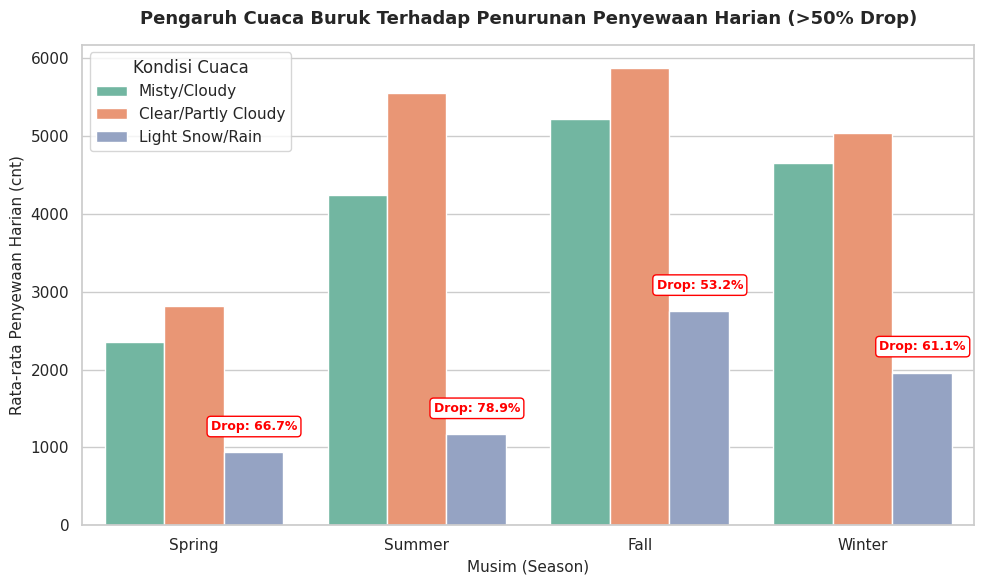

In [16]:
sns.set_theme(style="whitegrid")

# 1. Menghitung Pivot & Drop %
p1_df = day_df.pivot_table(index='season', columns='weathersit', values='cnt', aggfunc='mean')
p1_df['Drop_Percent'] = ((p1_df['Clear/Partly Cloudy'] - p1_df['Light Snow/Rain']) / p1_df['Clear/Partly Cloudy']) * 100

# 2. Plot Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=day_df,
    x='season',
    y='cnt',
    hue='weathersit',
    estimator='mean',
    errorbar=None,
    palette='Set2',
    ax=ax
)

ax.set_title('Pengaruh Cuaca Buruk Terhadap Penurunan Penyewaan Harian (>50% Drop)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Musim (Season)', fontsize=11)
ax.set_ylabel('Rata-rata Penyewaan Harian (cnt)', fontsize=11)
ax.legend(title='Kondisi Cuaca', loc='upper left')

seasons = ['Spring', 'Summer', 'Fall', 'Winter']
for i, season in enumerate(seasons):
    drop_val = p1_df.loc[season, 'Drop_Percent']
    blue_bar_height = p1_df.loc[season, 'Light Snow/Rain'] # Tinggi bar biru

    ax.text(
        i + 0.27, blue_bar_height + 250, f'Drop: {drop_val:.1f}%',
        ha='center', va='bottom', fontsize=9, fontweight='bold',
        color='red', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='red')
    )

plt.tight_layout()
plt.show()

### Grafik Perbandingan Jam Sibuk Pengguna Registered (Hari Kerja) vs Casual (Hari Libur)

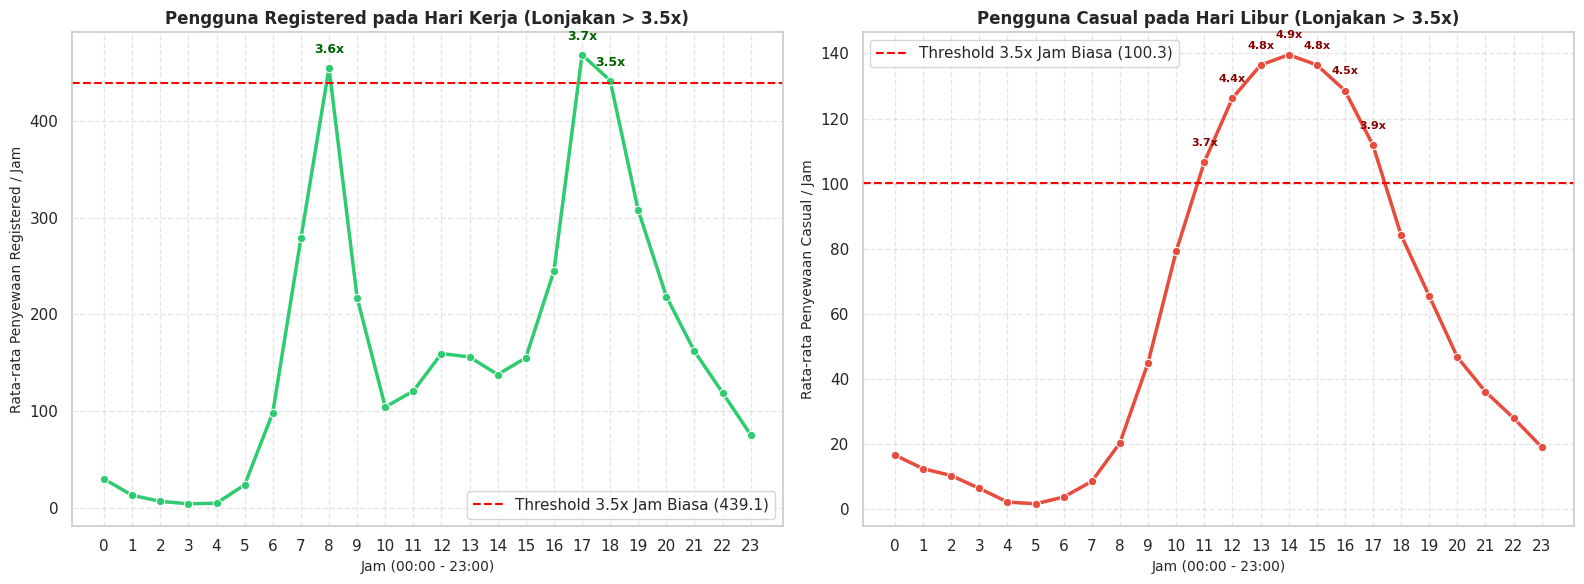

In [17]:
# Code Visualisasi Pertanyaan 2 (Line Chart Threshold 3.5x)
reg_work = hour_df[hour_df['workingday'] == 1].groupby('hr')['registered'].mean().reset_index()
cas_holiday = hour_df[hour_df['workingday'] == 0].groupby('hr')['casual'].mean().reset_index()

offpeak_reg_mean = reg_work[~reg_work['hr'].isin([8, 17, 18])]['registered'].mean()
offpeak_cas_mean = cas_holiday[~cas_holiday['hr'].isin(list(range(11, 18)))]['casual'].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Registered (Hari Kerja)
sns.lineplot(data=reg_work, x='hr', y='registered', marker='o', color='#2ecc71', linewidth=2.5, ax=ax1)
ax1.axhline(offpeak_reg_mean * 3.5, color='red', linestyle='--', label=f'Threshold 3.5x Jam Biasa ({offpeak_reg_mean*3.5:.1f})')
ax1.set_title('Pengguna Registered pada Hari Kerja (Lonjakan > 3.5x)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Jam (00:00 - 23:00)', fontsize=10)
ax1.set_ylabel('Rata-rata Penyewaan Registered / Jam', fontsize=10)
ax1.set_xticks(range(0, 24))
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

for hr in [8, 17, 18]:
    val = reg_work[reg_work['hr'] == hr]['registered'].values[0]
    ratio = val / offpeak_reg_mean
    ax1.text(hr, val + 15, f'{ratio:.1f}x', ha='center', fontsize=9, fontweight='bold', color='darkgreen')

# Plot 2: Casual (Hari Libur)
sns.lineplot(data=cas_holiday, x='hr', y='casual', marker='o', color='#e74c3c', linewidth=2.5, ax=ax2)
ax2.axhline(offpeak_cas_mean * 3.5, color='red', linestyle='--', label=f'Threshold 3.5x Jam Biasa ({offpeak_cas_mean*3.5:.1f})')
ax2.set_title('Pengguna Casual pada Hari Libur (Lonjakan > 3.5x)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Jam (00:00 - 23:00)', fontsize=10)
ax2.set_ylabel('Rata-rata Penyewaan Casual / Jam', fontsize=10)
ax2.set_xticks(range(0, 24))
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

for hr in range(11, 18):
    val = cas_holiday[cas_holiday['hr'] == hr]['casual'].values[0]
    ratio = val / offpeak_cas_mean
    ax2.text(hr, val + 5, f'{ratio:.1f}x', ha='center', fontsize=8, fontweight='bold', color='darkred')

plt.tight_layout()
plt.show()

### Heatmap Korelasi Variabel Lingkungan & Peminjaman

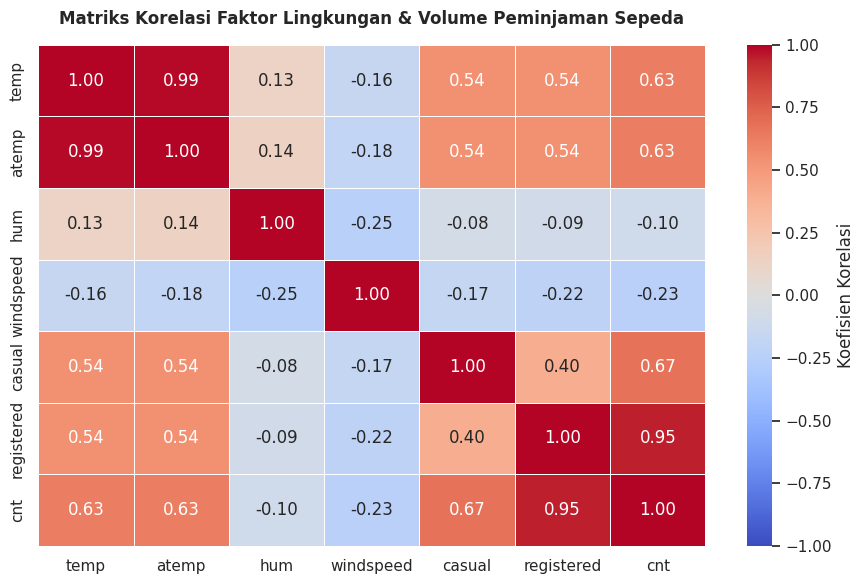

In [18]:
plt.figure(figsize=(9, 6))

# Menghitung korelasi kolom numerik
env_features = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
corr_matrix = day_df[env_features].corr()

# Membuat Heatmap dengan Seaborn
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Koefisien Korelasi'}
)

plt.title('Matriks Korelasi Faktor Lingkungan & Volume Peminjaman Sepeda', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Line Chart Tren Pertumbuhan Bulanan (2011 vs 2012)

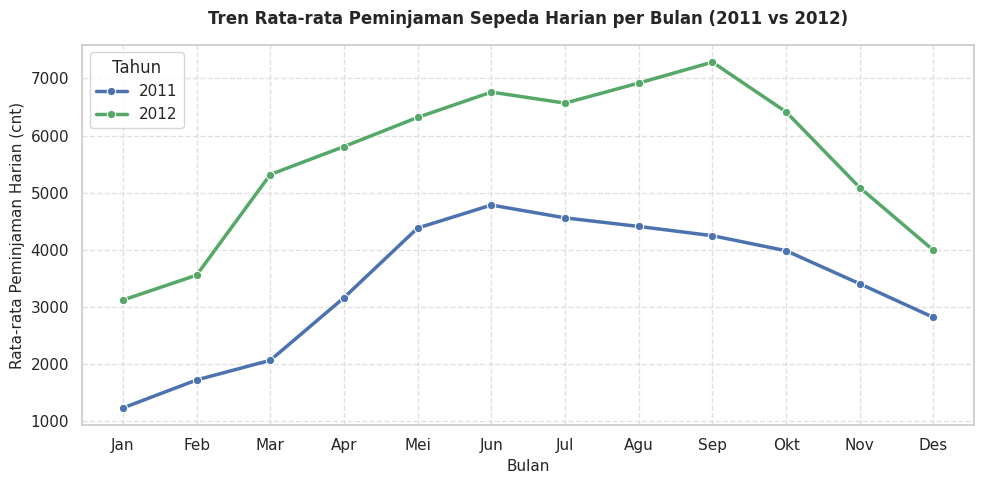

In [19]:
plt.figure(figsize=(10, 5))

# Data agregasi rata-rata peminjaman per bulan dan tahun
monthly_trend = day_df.groupby(['mnth', 'yr'])['cnt'].mean().reset_index()

# Plot Multi-Line Chart
sns.lineplot(
    data=monthly_trend,
    x='mnth',
    y='cnt',
    hue='yr',
    marker='o',
    palette=['#4C72B0', '#55A868'],
    linewidth=2.5
)

# Kustomisasi Sumbu dan Label
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']
plt.xticks(ticks=range(1, 13), labels=month_names)
plt.title('Tren Rata-rata Peminjaman Sepeda Harian per Bulan (2011 vs 2012)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Bulan', fontsize=11)
plt.ylabel('Rata-rata Peminjaman Harian (cnt)', fontsize=11)
plt.legend(title='Tahun', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Insight:**
- **Pengaruh Cuaca Buruk** : Light Snow/Rain terbukti memangkas penyewaan harian di atas 50% pada seluruh musim dibanding cuaca cerah. Penurunan paling parah dialami musim Summer (turun 78.9%), yang mengindikasikan sensitivitas aktivitas luar ruangan pengguna terhadap hujan/salju.
- **Lonjakan Jam Sibuk :**
1. Pengguna terdaftar (*Registered*) di hari kerja terkonsentrasi sangat tajam pada jam pergi/pulang kerja (08:00, 17:00, 18:00) dengan lonjakan hingga 3.7x lipat dari jam biasa.
2. Pengguna kasual (*Casual*) di hari libur terdistribusi lebih merata sepanjang siang hingga sore hari (11:00–17:00) dengan puncak lonjakan mencapai 4.9x lipat pada jam 14:00.
*   **Korelasi Parameter Lingkungan (Multivariate Heatmap)**: Temperatur suhu (temp = 0.63 dan atemp = 0.63) menjadi faktor cuaca paling dominan yang mendorong peningkatan volume sewa (cnt), sedangkan kelembapan udara (hum = -0.10) dan kecepatan angin (windspeed = -0.24) memberikan pengaruh negatif ringan terhadap minat peminjaman sepeda.
*   **Tren Pertumbuhan Antar-Tahun (Line Chart 2011 vs 2012)**: Terjadi ekspansi bisnis yang konsisten di mana rata-rata volume peminjaman harian pada tahun 2012 selalu mengungguli tahun 2011 di setiap bulannya, dengan pola musiman yang selaras yaitu mencapai puncak tertinggi pada kuartal 3 (musim Summer dan Fall) dan terendah pada kuartal 1 (Spring/Winter).



## Conclusion & Recommendation

### Conclusion:
- **Conclusion Pertanyaan 1:**  
  Persentase penurunan rata-rata penyewaan sepeda harian saat cuaca buruk (*Light Snow/Rain*) dibandingkan cuaca cerah (*Clear/Partly Cloudy*) **terbukti konsisten melebihi 50% di seluruh musim** sepanjang periode 2011–2012. Penurunan tertinggi dialami pada musim **Summer (78.93%)**, diikuti oleh **Spring (66.75%)**, **Winter (61.11%)**, dan **Fall (53.19%)**.
  
- **Conclusion Pertanyaan 2:**  
  Perbedaan pola jam sibuk antara kedua kelompok pengguna terlihat sangat signifikan:
 1. **Pengguna Registered (Hari Kerja):** Lonjakan di atas **3.5x lipat** dibanding jam biasa terjadi secara sangat tajam pada 3 jam spesifik, yaitu **08:00 Pagi (3.63x)**, **17:00 Sore (3.73x)**, dan **18:00 Sore (3.52x)** yang bertepatan dengan jam komuter berangkat dan pulang kerja.
 2. **Pengguna Casual (Hari Libur):** Lonjakan di atas **3.5x lipat** dibanding jam biasa bertahan stabil dan lebih lama selama 7 jam berturut-turut dari **11:00 Siang hingga 17:00 Sore**, dengan puncak lonjakan tertinggi mencapai **4.87x lipat** pada jam **14:00 Siang**.
*   Berdasarkan uji korelasi, **temperatur lingkungan (suhu)** merupakan faktor eksternal paling krusial yang berdampak positif pada tingginya volume peminjaman, melebihi faktor kelembapan maupun kecepatan angin.
*   Secara bisnis, performa penyewaan sepeda menunjukkan **tren pertumbuhan (growth) yang sangat positif**, terbukti dari rata-rata peminjaman harian di tahun 2012 yang secara konsisten selalu lebih tinggi dibandingkan tahun 2011 pada setiap bulannya.



**Rekomendasi Action Item:**
1. **Strategi Pengelolaan Dampak Cuaca Buruk (Mitigasi Penurunan >50%)**:
   - **Integrasi Peringatan Cuaca & Sistem Notifikasi Aplikasi (Early Warning):**
     Menyediakan fitur notifikasi peringatan cuaca buruk secara real-time pada aplikasi seluler untuk mengimbau pengguna agar merencanakan perjalanan lebih awal atau mempersiapkan perlengkapan keselamatan sebelum hujan/salju turun.
   - **Penjadwalan Maintenance Armada Saat Low-Demand (Downtime Efficiency):**
     Memanfaatkan periode sepi saat cuaca buruk (volume sewa turun >50%) sebagai waktu optimal bagi tim operasional untuk melakukan perawatan rutin, pengecekan rem/ban, serta pengisian daya armada tanpa mengganggu ketersediaan sepeda di hari cerah.
2. **Optimasi Manajemen Armada & Logistik Sepeda (Menghadapi Lonjakan >3.5x):**
   - **Hari Kerja (Persiapan Komuter):** Memastikan penumpukan armada sepeda (*rebalancing*) berada di stasiun permukiman/stasiun transit sebelum jam **08:00 Pagi**, serta di kawasan perkantoran sebelum jam **17:00 Sore**.
   - **Hari Libur (Persiapan Rekreasi):** Mengalokasikan ketersediaan unit sepeda di area wisata, taman, dan pusat perbelanjaan mulai jam **10:30 Pagi** untuk mengantisipasi lonjakan pengguna kasual yang berlangsung lama (11:00–17:00).

In [20]:
# ==============================================================================
# PROSES EKSPOR DATA UNTUK STREAMLIT DASHBOARD
# ==============================================================================

# 1. Pastikan kolom tanggal berformat datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# 2. Mapping nilai kategorikal agar siap pakai di Dashboard
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_mapping = {
    1: 'Clear/Partly Cloudy',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Severe Weather'
}

# Terapkan mapping jika kolom masih berupa angka
if day_df['season'].dtype != 'object':
    day_df['season'] = day_df['season'].map(season_mapping)
if day_df['weathersit'].dtype != 'object':
    day_df['weathersit'] = day_df['weathersit'].map(weather_mapping)

if hour_df['season'].dtype != 'object':
    hour_df['season'] = hour_df['season'].map(season_mapping)
if hour_df['weathersit'].dtype != 'object':
    hour_df['weathersit'] = hour_df['weathersit'].map(weather_mapping)

# 3. Ekspor Data Harian Utama sebagai 'main_data.csv'
day_df.to_csv("main_data.csv", index=False)

# 4. Ekspor Data Jam-jaman sebagai 'hour_cleaned.csv' (untuk analisis jam di Streamlit)
hour_df.to_csv("hour_cleaned.csv", index=False)